Keystroke: (408, 6) unique users: 51
Mouse: (1676, 8) unique users: 10


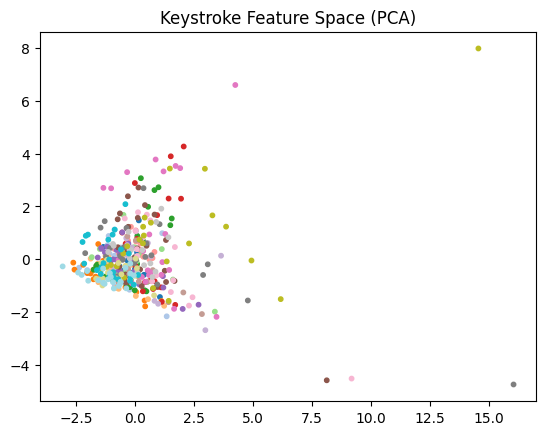

Keystroke silhouette score: -0.29104384779930115


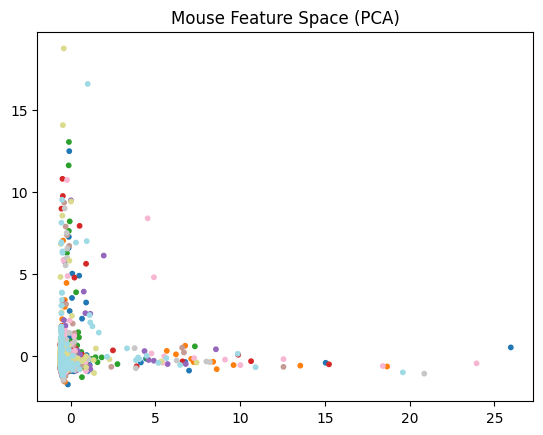

Mouse silhouette score: -0.11410032957792282


In [2]:
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# Load features
keys = np.load("data/features_keystroke.npz", allow_pickle=True)
mouse = np.load("data/features_mouse.npz", allow_pickle=True)

Xk, yk = keys["features"], keys["user_id"]
Xm, ym = mouse["features"], mouse["user_id"]

print("Keystroke:", Xk.shape, "unique users:", len(np.unique(yk)))
print("Mouse:", Xm.shape, "unique users:", len(np.unique(ym)))

# --- Keystroke PCA/TSNE visualization ---
sc = StandardScaler().fit_transform(Xk)
Z = PCA(n_components=2).fit_transform(sc)
plt.scatter(Z[:,0], Z[:,1], c=pd.factorize(yk)[0], s=10, cmap='tab20')
plt.title("Keystroke Feature Space (PCA)")
plt.show()

print("Keystroke silhouette score:", silhouette_score(sc, pd.factorize(yk)[0]))

# --- Mouse PCA/TSNE visualization ---
scm = StandardScaler().fit_transform(Xm)
Zm = PCA(n_components=2).fit_transform(scm)
plt.scatter(Zm[:,0], Zm[:,1], c=pd.factorize(ym)[0], s=10, cmap='tab20')
plt.title("Mouse Feature Space (PCA)")
plt.show()

print("Mouse silhouette score:", silhouette_score(scm, pd.factorize(ym)[0]))

In [1]:
# ============================================================
# 02_features.ipynb
# Adaptive Continuous Authentication — Feature Extraction
# ============================================================

"""
Goal:
  - Load unified_auth_stream.parquet (from 01_data_load_keystroke_mouse.ipynb)
  - Extract per-session and per-modality behavioral features
  - Save to data/features_{modality}.npz for modeling

Outputs:
  data/features_keystroke.npz
  data/features_mouse.npz
"""

# ============================================================
# Imports
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from scipy.stats import skew, kurtosis, entropy

DATA_DIR = Path("data")
UNIFIED_PATH = DATA_DIR / "unified_auth_stream.parquet"

# ============================================================
# SECTION 1 — Load unified dataset
# ============================================================
df = pd.read_parquet(UNIFIED_PATH)
print(f"✅ Loaded unified dataset: {len(df)} rows, modalities = {df['modality'].unique()}")

# Ensure clean typing
df["user_id"] = df["user_id"].astype(str)
df["session_id"] = df["session_id"].astype(str)
df["modality"] = df["modality"].astype(str)

# ============================================================
# SECTION 2 — Helper functions
# ============================================================

def safe_stats(arr):
    """Return mean, std, skew, kurtosis, entropy safely."""
    arr = np.asarray(arr, dtype=np.float32)
    arr = arr[np.isfinite(arr)]
    if len(arr) == 0:
        return np.zeros(5)
    # Normalize histogram for entropy
    hist, _ = np.histogram(arr, bins=20, density=True)
    hist = hist + 1e-8
    return np.array([
        np.mean(arr),
        np.std(arr),
        skew(arr),
        kurtosis(arr),
        entropy(hist)
    ], dtype=np.float32)

# ============================================================
# SECTION 3 — Keystroke Feature Extraction
# ============================================================

def extract_keystroke_features(df_keys: pd.DataFrame) -> pd.DataFrame:
    """
    Compute per-session keystroke statistics:
      - Mean/std/skew/kurtosis/entropy of dwell & flight latencies
      - Counts of missing keys (robustness)
    """
    print("🔹 Extracting keystroke features...")

    # Flatten numpy arrays
    df_keys = df_keys.copy()
    df_keys["feat_len"] = df_keys["features"].apply(lambda f: len(f) if isinstance(f, (list, np.ndarray)) else 0)

    feature_list = []
    for (user, sess), group in tqdm(df_keys.groupby(["user_id", "session_id"])):
        all_feats = np.vstack(group["features"].to_numpy())
        all_feats = all_feats[np.isfinite(all_feats)]
        stats = safe_stats(all_feats)
        feature_list.append({
            "user_id": user,
            "session_id": sess,
            "f_mean": stats[0],
            "f_std": stats[1],
            "f_skew": stats[2],
            "f_kurt": stats[3],
            "f_entropy": stats[4],
            "n_samples": len(group)
        })

    df_out = pd.DataFrame(feature_list)
    print(f"✅ Extracted {len(df_out)} keystroke session-level features.")
    return df_out


# ============================================================
# SECTION 4 — Mouse Feature Extraction
# ============================================================

def extract_mouse_features(df_mouse: pd.DataFrame) -> pd.DataFrame:
    """
    Compute per-session mouse trajectory features:
      - Velocity / acceleration stats
      - Path curvature and idle time
    """
    print("🔹 Extracting mouse features...")

    feature_list = []
    for (user, sess), group in tqdm(df_mouse.groupby(["user_id", "session_id"])):
        g = group.sort_values("timestamp")
        x, y = g["features"].apply(lambda a: a[0]).to_numpy(), g["features"].apply(lambda a: a[1]).to_numpy()
        t = g["timestamp"].to_numpy(dtype=np.float32)
        if len(t) < 2:
            continue

        dt = np.diff(t)
        dx = np.diff(x)
        dy = np.diff(y)
        vel = np.sqrt(dx**2 + dy**2) / (dt + 1e-5)
        acc = np.diff(vel) / (dt[1:] + 1e-5)

        # curvature: change in direction between consecutive points
        directions = np.arctan2(dy, dx)
        dtheta = np.diff(directions)
        curvature = np.abs(np.unwrap(dtheta))

        # idle times: where dt > 1s
        idle_ratio = np.mean(dt > 1.0)

        stats_v = safe_stats(vel)
        stats_a = safe_stats(acc)
        stats_c = safe_stats(curvature)

        feature_list.append({
            "user_id": user,
            "session_id": sess,
            "vel_mean": stats_v[0],
            "vel_std": stats_v[1],
            "acc_mean": stats_a[0],
            "acc_std": stats_a[1],
            "curv_mean": stats_c[0],
            "curv_std": stats_c[1],
            "idle_ratio": idle_ratio,
            "n_points": len(g)
        })

    df_out = pd.DataFrame(feature_list)
    print(f"✅ Extracted {len(df_out)} mouse session-level features.")
    return df_out


# ============================================================
# SECTION 5 — Run Feature Extraction
# ============================================================

df_keys = df[df["modality"] == "keystroke"]
df_mouse = df[df["modality"] == "mouse"]

features_keys = extract_keystroke_features(df_keys)
features_mouse = extract_mouse_features(df_mouse)

# ============================================================
# SECTION 6 — Save Features
# ============================================================

def save_npz(df_feat: pd.DataFrame, name: str):
    path = DATA_DIR / f"features_{name}.npz"
    np.savez_compressed(
        path,
        user_id=df_feat["user_id"].values,
        session_id=df_feat["session_id"].values,
        features=df_feat.drop(columns=["user_id", "session_id"]).to_numpy(dtype=np.float32)
    )
    print(f"💾 Saved {name} features → {path.resolve()}")

save_npz(features_keys, "keystroke")
save_npz(features_mouse, "mouse")

print("✅ Feature extraction complete.")

✅ Loaded unified dataset: 4630329 rows, modalities = ['mouse' 'keystroke']
🔹 Extracting keystroke features...


100%|█████████████████████████████████████████████████████████████████████████████████| 408/408 [00:00<00:00, 2575.89it/s]


✅ Extracted 408 keystroke session-level features.
🔹 Extracting mouse features...


  0%|                                                                                            | 0/1676 [00:00<?, ?it/s]/Users/vkhawarey/Documents/git/moviecruncher/dataviz/multi_modal_hci_gen/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1233: RuntimeWarning: overflow encountered in multiply
  s *= a_zero_mean
/Users/vkhawarey/Documents/git/moviecruncher/dataviz/multi_modal_hci_gen/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1231: RuntimeWarning: overflow encountered in square
  s = s**2
  0%|                                                                                    | 1/1676 [00:00<10:29,  2.66it/s]/Users/vkhawarey/Documents/git/moviecruncher/dataviz/multi_modal_hci_gen/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/Users/vkhawarey/Documents/git/moviecruncher/dataviz/multi_modal_hci_gen/.venv/lib/python3.13/site-package

✅ Extracted 1676 mouse session-level features.
💾 Saved keystroke features → /Users/vkhawarey/Documents/git/moviecruncher/dataviz/adaptive_auth/data/features_keystroke.npz
💾 Saved mouse features → /Users/vkhawarey/Documents/git/moviecruncher/dataviz/adaptive_auth/data/features_mouse.npz
✅ Feature extraction complete.
